# 🏎️ Exploration des Données - Cityscapes Dataset

## Objectifs
1. Comprendre la structure du dataset
2. Travailler avec les **8 catégories principales** (pas les 19 classes)
3. Analyser la distribution des catégories
4. Visualiser des exemples

## 📦 Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter, defaultdict
import pandas as pd
from tqdm import tqdm

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12

print('✅ Imports réussis !')

✅ Imports réussis !


## 📂 Chemins du dataset

In [2]:
DATA_ROOT = Path('../data')
TRAIN_DIR = DATA_ROOT / 'gtFine' / 'train'
TEST_DIR = DATA_ROOT / 'gtFine' / 'test'

train_cities = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
test_cities = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir()])

print(f'🏙️  Villes train ({len(train_cities)}) : {train_cities[:5]}... ({len(train_cities)-5} autres)')
print(f'🏙️  Villes test ({len(test_cities)}) : {test_cities}')

🏙️  Villes train (18) : ['aachen', 'bochum', 'bremen', 'cologne', 'darmstadt']... (13 autres)
🏙️  Villes test (6) : ['berlin', 'bielefeld', 'bonn', 'leverkusen', 'mainz', 'munich']


## 🎨 Les 8 Catégories Cityscapes

Selon les instructions de Franck, on utilise les **8 catégories principales**, pas les 19 sous-classes :

1. **flat** - route, trottoir, parking
2. **human** - piétons, cyclistes
3. **vehicle** - voitures, camions, bus, trains, motos, vélos
4. **construction** - bâtiments, murs, clôtures
5. **object** - poteaux, feux, panneaux
6. **nature** - végétation, terrain
7. **sky** - ciel
8. **void** - pixels ignorés

In [3]:
# Mapping labelId → catégorie (8 catégories)
LABEL_TO_CATEGORY = {
    0: 'void', 1: 'void', 2: 'void', 3: 'void', 4: 'void', 5: 'void', 6: 'void',
    7: 'flat', 8: 'flat', 9: 'flat', 10: 'flat',
    11: 'construction', 12: 'construction', 13: 'construction', 14: 'construction', 15: 'construction', 16: 'construction',
    17: 'object', 18: 'object', 19: 'object', 20: 'object',
    21: 'nature', 22: 'nature',
    23: 'sky',
    24: 'human', 25: 'human',
    26: 'vehicle', 27: 'vehicle', 28: 'vehicle', 29: 'vehicle', 30: 'vehicle', 31: 'vehicle', 32: 'vehicle', 33: 'vehicle',
}

# Couleurs pour les 8 catégories
CATEGORY_COLORS = {
    'void': (0, 0, 0),
    'flat': (128, 64, 128),
    'construction': (70, 70, 70),
    'object': (153, 153, 153),
    'nature': (107, 142, 35),
    'sky': (70, 130, 180),
    'human': (220, 20, 60),
    'vehicle': (0, 0, 142),
}

# Mapping catégorie → ID (0-7)
CATEGORY_TO_ID = {
    'void': 0,
    'flat': 1,
    'construction': 2,
    'object': 3,
    'nature': 4,
    'sky': 5,
    'human': 6,
    'vehicle': 7,
}

print('📋 Les 8 catégories :\n')
for cat_name, cat_id in CATEGORY_TO_ID.items():
    color = CATEGORY_COLORS[cat_name]
    print(f'  [{cat_id}] {cat_name:<15} - RGB{color}')

📋 Les 8 catégories :

  [0] void            - RGB(0, 0, 0)
  [1] flat            - RGB(128, 64, 128)
  [2] construction    - RGB(70, 70, 70)
  [3] object          - RGB(153, 153, 153)
  [4] nature          - RGB(107, 142, 35)
  [5] sky             - RGB(70, 130, 180)
  [6] human           - RGB(220, 20, 60)
  [7] vehicle         - RGB(0, 0, 142)


In [4]:
# Fonction de conversion labelIds → catégories
def convert_to_categories(label_mask):
    """Convertit un masque labelIds (0-33) en catégories (0-7)."""
    h, w = label_mask.shape
    category_mask = np.zeros((h, w), dtype=np.uint8)
    
    for label_id, category in LABEL_TO_CATEGORY.items():
        category_id = CATEGORY_TO_ID[category]
        category_mask[label_mask == label_id] = category_id
    
    return category_mask

# Créer une palette de couleurs pour les 8 catégories
def create_category_palette():
    palette = np.zeros((256, 3), dtype=np.uint8)
    for cat_name, cat_id in CATEGORY_TO_ID.items():
        palette[cat_id] = CATEGORY_COLORS[cat_name]
    return palette

CATEGORY_PALETTE = create_category_palette()
print('✅ Palette de catégories créée !')

✅ Palette de catégories créée !


## 📊 Analyse de la distribution des catégories

In [5]:
# Analyser la distribution par catégorie
print('🔍 Analyse de la distribution des catégories...')
print('   (analyse ~2700 images, peut prendre 2-3 minutes)\n')

category_pixel_counts = defaultdict(int)
total_pixels = 0
nb_images = 0

for city in tqdm(train_cities, desc='Villes'):
    city_dir = TRAIN_DIR / city
    label_files = sorted(city_dir.glob('*_labelIds.png'))[:150]
    
    for label_file in label_files:
        label_mask = np.array(Image.open(label_file))
        category_mask = convert_to_categories(label_mask)
        
        unique, counts = np.unique(category_mask, return_counts=True)
        for cat_id, count in zip(unique, counts):
            category_pixel_counts[int(cat_id)] += count
        
        total_pixels += category_mask.size
        nb_images += 1

print(f'\n✅ Analyse terminée !')
print(f'   • {nb_images} images')
print(f'   • {total_pixels:,} pixels')

🔍 Analyse de la distribution des catégories...
   (analyse ~2700 images, peut prendre 2-3 minutes)



Villes: 100%|██████████| 18/18 [01:27<00:00,  4.84s/it]


✅ Analyse terminée !
   • 2305 images
   • 4,833,935,360 pixels


In [6]:
# Créer un DataFrame
cat_stats = []
id_to_name = {v: k for k, v in CATEGORY_TO_ID.items()}

for cat_id in sorted(category_pixel_counts.keys()):
    cat_name = id_to_name[cat_id]
    count = category_pixel_counts[cat_id]
    pct = (count / total_pixels) * 100
    
    cat_stats.append({
        'id': cat_id,
        'categorie': cat_name,
        'pixels': count,
        'percentage': pct,
        'use': 'ignore' if cat_name == 'void' else 'train'
    })

df_cat = pd.DataFrame(cat_stats).sort_values('pixels', ascending=False)

print('\n📊 Distribution des 8 catégories :\n')
print(df_cat.to_string(index=False))

print('\n🔝 Top 3 catégories :')
for _, row in df_cat[df_cat['use'] == 'train'].head(3).iterrows():
    print(f"   {row['categorie']:<15} : {row['percentage']:.2f}%")


📊 Distribution des 8 catégories :

 id    categorie     pixels  percentage    use
  1         flat 1877996383   38.850258  train
  2 construction 1073139964   22.200131  train
  4       nature  736834421   15.242951  train
  0         void  483592798   10.004122 ignore
  7      vehicle  352897059    7.300409  train
  5          sky  165913043    3.432256  train
  3       object   85819835    1.775362  train
  6        human   57741857    1.194510  train

🔝 Top 3 catégories :
   flat            : 38.85%
   construction    : 22.20%
   nature          : 15.24%


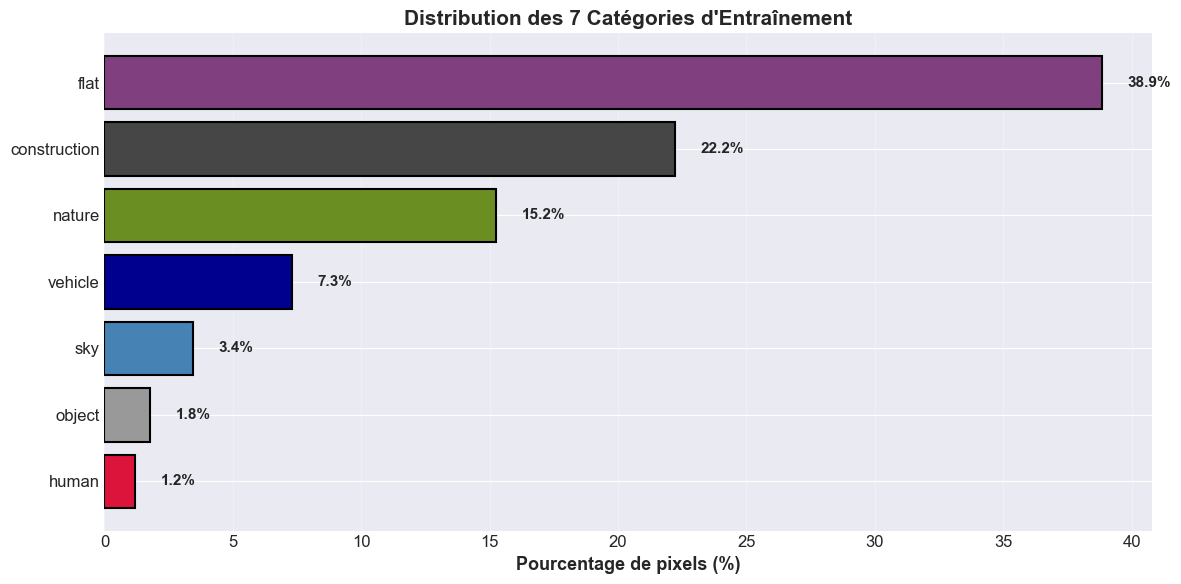


⚠️  Déséquilibre : 32.5x
    → Utiliser une loss pondérée ou Focal Loss


In [7]:
# Visualisation
df_train_cat = df_cat[df_cat['use'] == 'train'].sort_values('percentage', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

colors = [np.array(CATEGORY_COLORS[cat]) / 255.0 for cat in df_train_cat['categorie']]

bars = ax.barh(df_train_cat['categorie'], df_train_cat['percentage'], color=colors, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Pourcentage de pixels (%)', fontweight='bold', fontsize=13)
ax.set_title('Distribution des 7 Catégories d\'Entraînement', fontweight='bold', fontsize=15)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Ajouter les valeurs sur les barres
for bar, pct in zip(bars, df_train_cat['percentage']):
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
            f'{pct:.1f}%', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

max_pct = df_train_cat['percentage'].max()
min_pct = df_train_cat['percentage'].min()
ratio = max_pct / min_pct

print(f'\n⚠️  Déséquilibre : {ratio:.1f}x')
print(f'    → Utiliser une loss pondérée ou Focal Loss')

## 🖼️ Visualisation d'exemples

In [8]:
# Récupérer 6 exemples
sample_images = []

for city in train_cities[:6]:
    city_dir = TRAIN_DIR / city
    label_files = sorted(city_dir.glob('*_labelIds.png'))
    
    if label_files:
        label_path = label_files[len(label_files)//2]
        color_path = label_path.parent / label_path.name.replace('_labelIds.png', '_color.png')
        
        if color_path.exists():
            sample_images.append({
                'city': city,
                'color': color_path,
                'label': label_path
            })

print(f'📸 {len(sample_images)} exemples récupérés')

📸 6 exemples récupérés


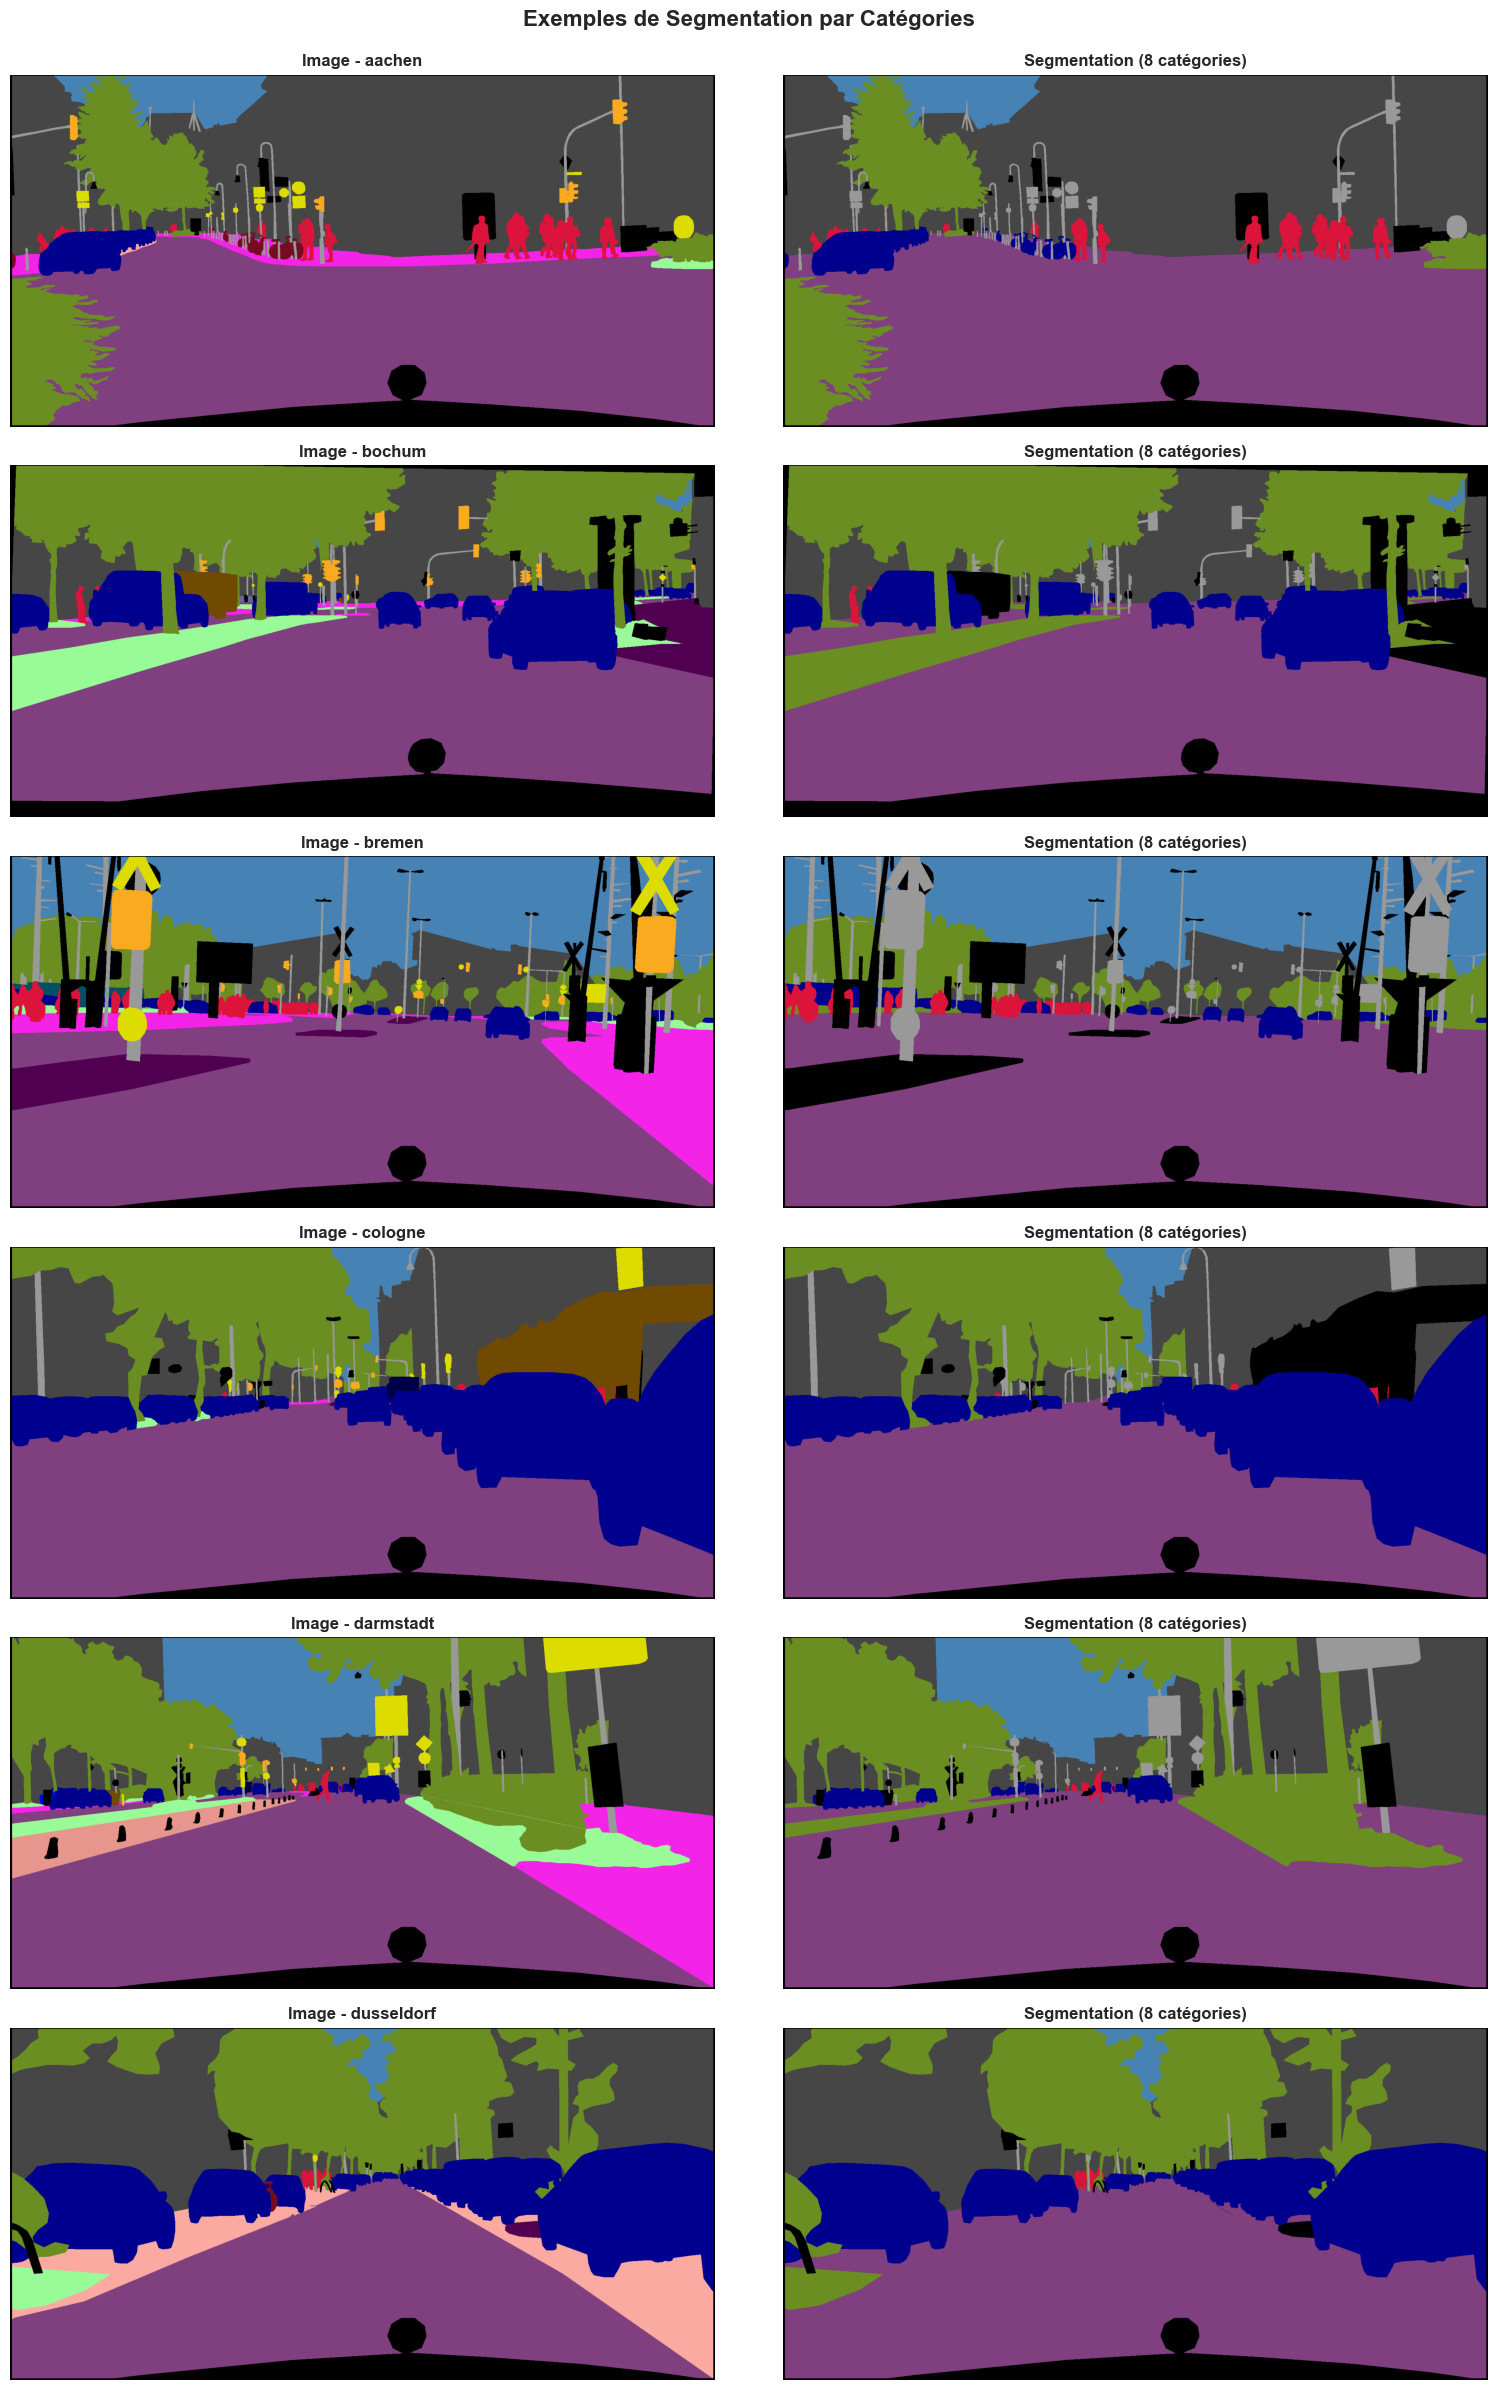

In [9]:
# Visualiser les exemples avec les 8 catégories
fig, axes = plt.subplots(len(sample_images), 2, figsize=(16, 4 * len(sample_images)))

if len(sample_images) == 1:
    axes = axes.reshape(1, -1)

for idx, sample in enumerate(sample_images):
    # Charger
    color_img = Image.open(sample['color'])
    label_mask = np.array(Image.open(sample['label']))
    category_mask = convert_to_categories(label_mask)
    
    # Appliquer la palette
    colored = CATEGORY_PALETTE[category_mask]
    
    # Affichage
    axes[idx, 0].imshow(color_img)
    axes[idx, 0].set_title(f"Image - {sample['city']}", fontweight='bold', fontsize=12)
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(colored)
    axes[idx, 1].set_title('Segmentation (8 catégories)', fontweight='bold', fontsize=12)
    axes[idx, 1].axis('off')

plt.suptitle('Exemples de Segmentation par Catégories', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 🔄 Comparaison : labelIds vs Catégories

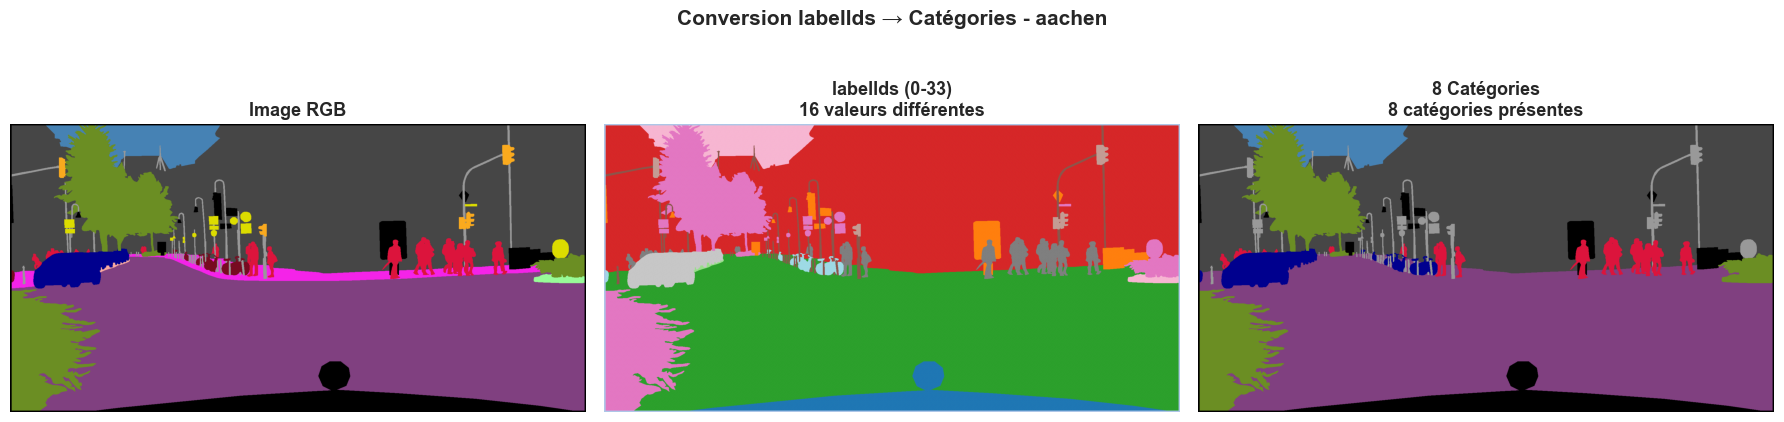


💡 Le modèle prédira 8 catégories (0-7), pas 19 classes !


In [10]:
# Montrer la conversion sur un exemple
example = sample_images[0]
label_mask = np.array(Image.open(example['label']))
category_mask = convert_to_categories(label_mask)
colored_cat = CATEGORY_PALETTE[category_mask]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Image
axes[0].imshow(Image.open(example['color']))
axes[0].set_title('Image RGB', fontweight='bold', fontsize=13)
axes[0].axis('off')

# labelIds brut
axes[1].imshow(label_mask, cmap='tab20', vmin=0, vmax=33)
axes[1].set_title(f'labelIds (0-33)\n{len(np.unique(label_mask))} valeurs différentes', fontweight='bold', fontsize=13)
axes[1].axis('off')

# Catégories
axes[2].imshow(colored_cat)
axes[2].set_title(f'8 Catégories\n{len(np.unique(category_mask))} catégories présentes', fontweight='bold', fontsize=13)
axes[2].axis('off')

plt.suptitle(f"Conversion labelIds → Catégories - {example['city']}", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Le modèle prédira 8 catégories (0-7), pas 19 classes !')

## ✅ Résumé

### Ce qu'on a appris :
1. Dataset : **2975 images train** sur 18 villes
2. On utilise **8 catégories**, pas 19 classes individuelles
3. Catégories dominantes : **flat** (route), **construction**, **nature**
4. Catégories minoritaires : **human**, **vehicle** (mais critiques !)
5. Déséquilibre important → **loss pondérée nécessaire**

### Prochaines étapes :
1. Créer un DataLoader qui convertit labelIds → catégories (0-7)
2. Implémenter une loss pondérée (Focal Loss ou Weighted CE)
3. Data augmentation
4. Entraîner un modèle U-Net à **8 sorties** (une par catégorie)